Realizziamo gli esercizi di esempio

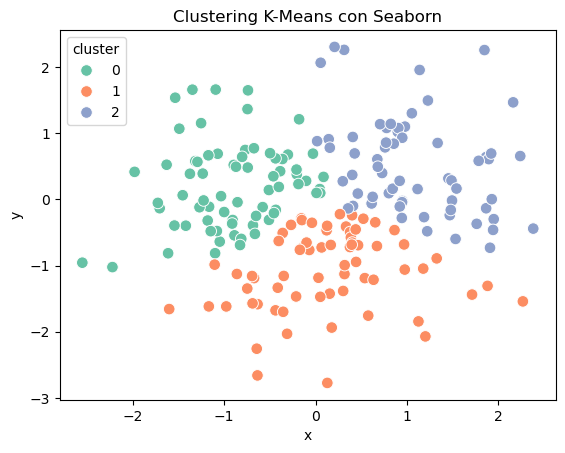

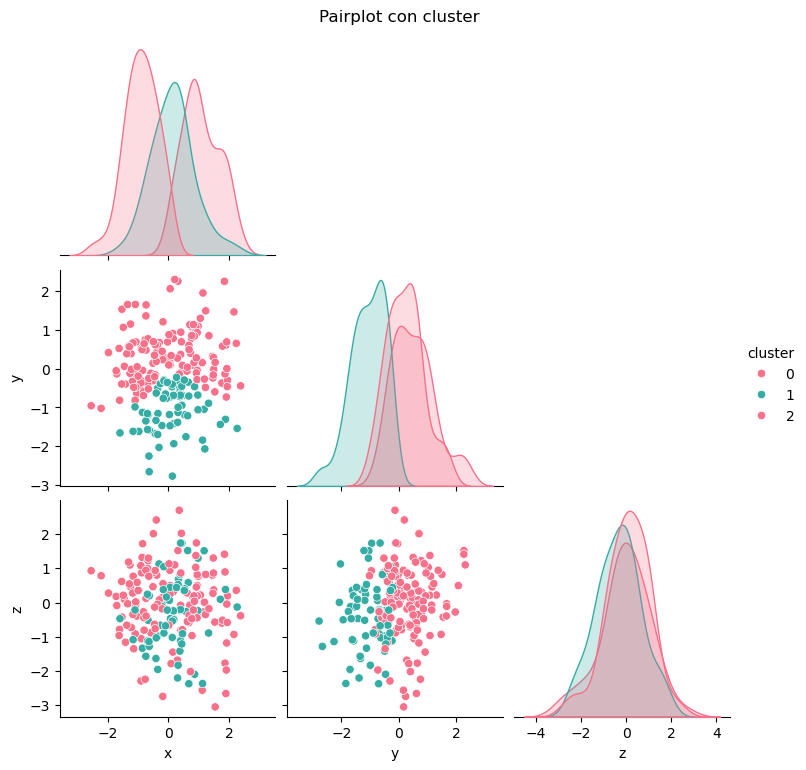

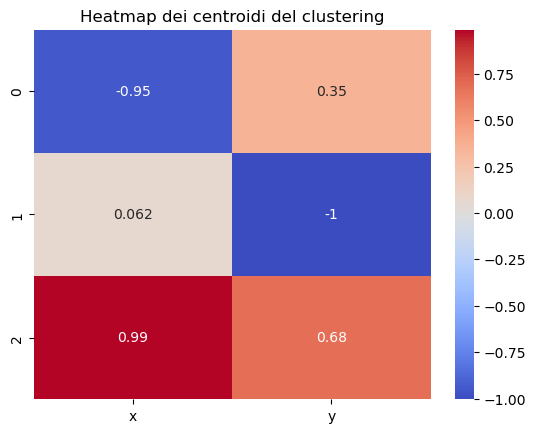

In [1]:
"""
Esempio 1: K-Means su 2 variabili + scatterplot colorato per cluster.
"""
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

np.random.seed(0)

df = pd.DataFrame({
    "x": np.random.normal(0, 1, 200),
    "y": np.random.normal(0, 1, 200)
})

# Standardizzazione (fondamentale con K-Means)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[["x", "y"]])

# K-Means
kmeans = KMeans(n_clusters=3, random_state=0, n_init=10)
df["cluster"] = kmeans.fit_predict(X_scaled)

# Plot
sns.scatterplot(data=df, x="x", y="y", hue="cluster", palette="Set2", s=70)
plt.title("Clustering K-Means con Seaborn")
plt.show()


"""
Esempio 2: aggiungo una variabile e uso pairplot con hue=cluster.
"""
df["z"] = np.random.normal(0, 1, 200)

sns.pairplot(df, hue="cluster", palette="husl", corner=True)
plt.suptitle("Pairplot con cluster", y=1.02)
plt.show()

"""
Esempio 3: heatmap dei centroidi (attenzione: sono standardizzati).
"""
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

centroids = pd.DataFrame(kmeans.cluster_centers_, columns=["x", "y"])

sns.heatmap(centroids, annot=True, cmap="coolwarm")
plt.title("Heatmap dei centroidi del clustering")
plt.show()


Passiamo ora agli esercizi assegnati

Centroidi (standardizzati):
[[-0.05021989 -0.88337647  0.34773781  0.2815273 ]
 [-1.01457897  0.85326268 -1.30498732 -1.25489349]
 [ 1.13597027  0.08842168  0.99615451  1.01752612]]


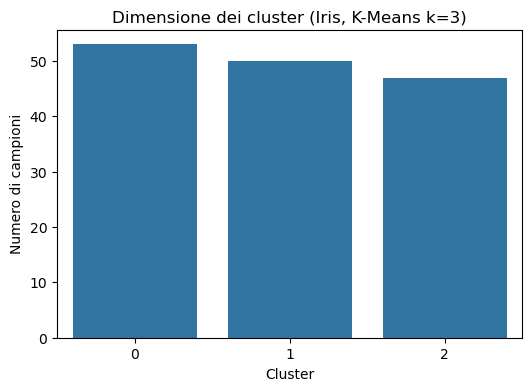

In [5]:
"""
Esercizio 1: K-Means su Iris con standardizzazione.
"""
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)

# 1) Standardizzazione
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)  # df contiene solo feature numeriche

# 2) K-Means
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
labels = kmeans.fit_predict(X_scaled)

# 3) Salvo etichette
df["Cluster"] = labels

print("Centroidi (standardizzati):")
print(kmeans.cluster_centers_)


plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Cluster", order=sorted(df["Cluster"].unique()))
plt.title("Dimensione dei cluster (Iris, K-Means k=3)")
plt.xlabel("Cluster")
plt.ylabel("Numero di campioni")
plt.show()

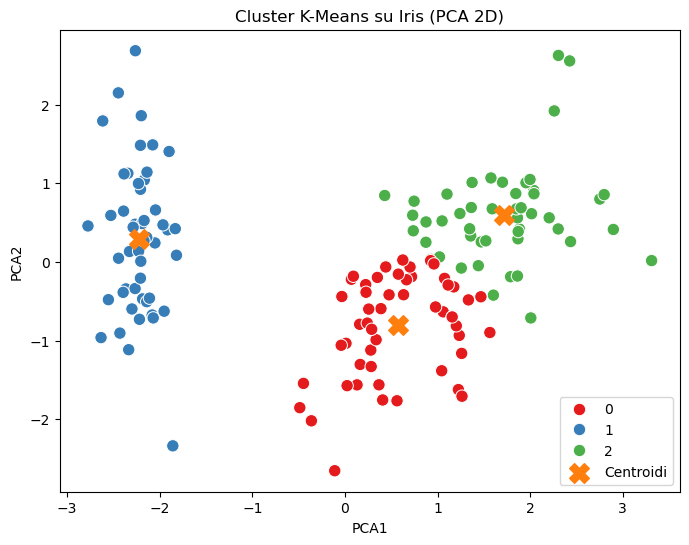

In [4]:
"""
Esercizio 2: PCA 2D per visualizzare i cluster + centroidi nello spazio PCA.
"""
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

# PCA su dati scalati
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

df["PCA1"] = X_pca[:, 0]
df["PCA2"] = X_pca[:, 1]

# Centroidi portati nello spazio PCA
centroids_pca = pca.transform(kmeans.cluster_centers_)

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x="PCA1", y="PCA2", hue="Cluster", palette="Set1", s=80)

# Nota: qui nel tuo prompt c='black'. È ok esteticamente.
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1], s=200, marker="X", label="Centroidi")

plt.title("Cluster K-Means su Iris (PCA 2D)")
plt.legend()
plt.show()

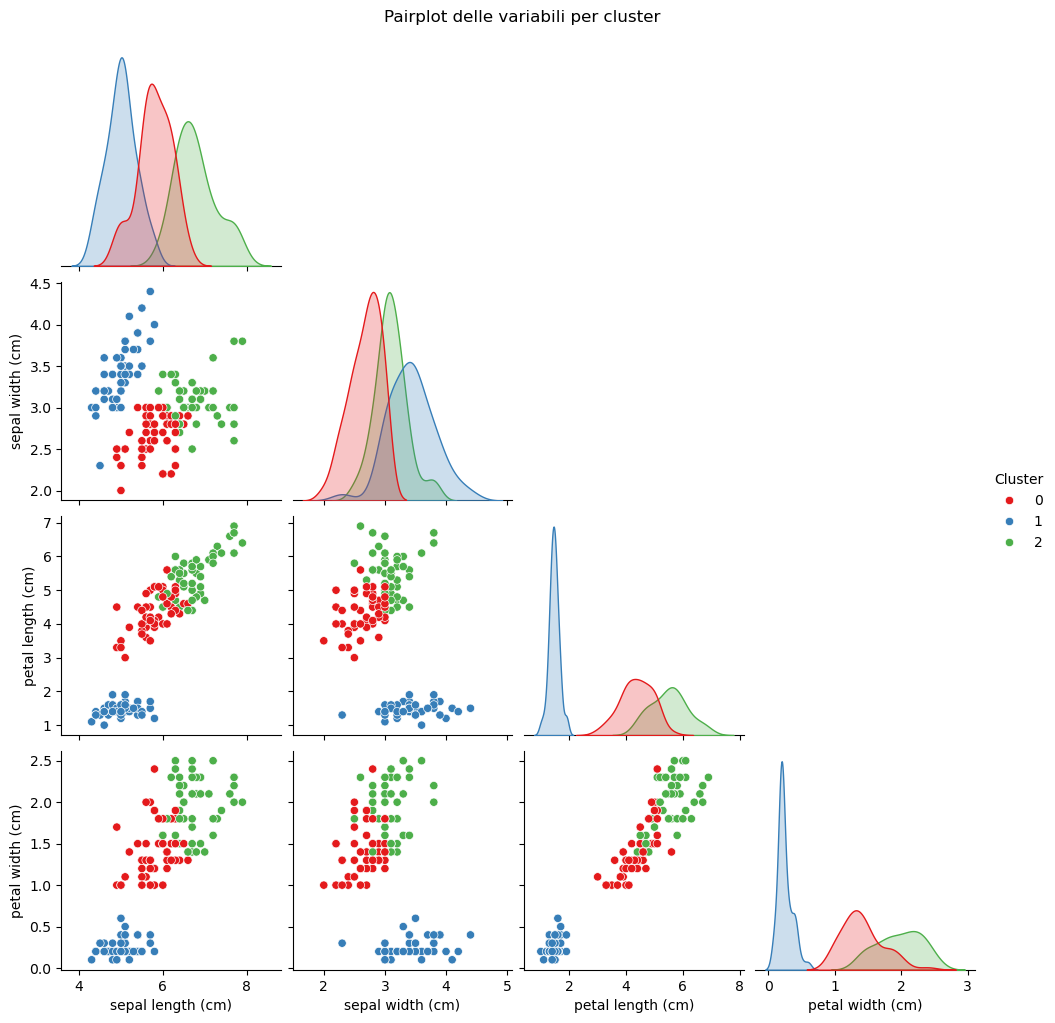

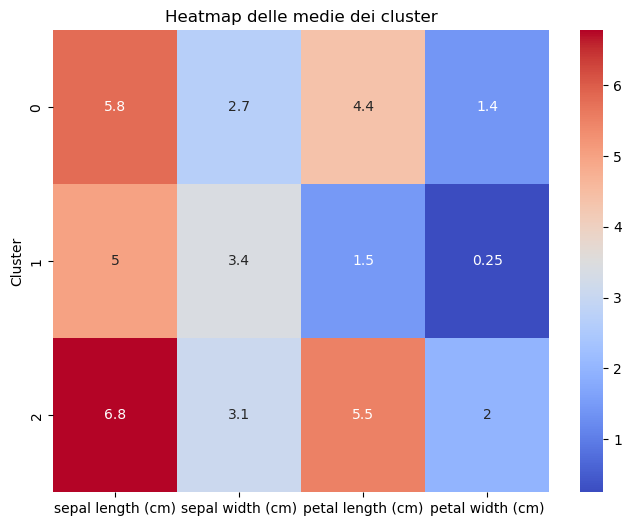

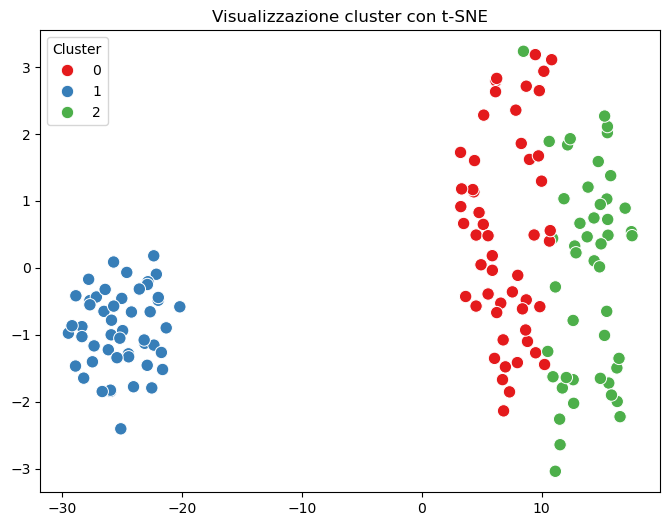

In [6]:
"""
Esercizio 3: analisi e visualizzazione dei cluster.
- Pairplot: separazione per coppie di variabili
- Heatmap: profili medi per cluster
- t-SNE: proiezione non-lineare in 2D
"""
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# Pairplot
sns.pairplot(df, vars=iris.feature_names, hue="Cluster", palette="Set1", corner=True)
plt.suptitle("Pairplot delle variabili per cluster", y=1.02)
plt.show()

# Heatmap profili
cluster_means = df.groupby("Cluster")[iris.feature_names].mean()

plt.figure(figsize=(8, 6))
sns.heatmap(cluster_means, annot=True, cmap="coolwarm")
plt.title("Heatmap delle medie dei cluster")
plt.show()

# t-SNE
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=df["Cluster"], palette="Set1", s=80)
plt.title("Visualizzazione cluster con t-SNE")
plt.show()